In [1]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord, Angle
from astropy.table import Table, vstack
from astropy.time import Time
from astropy.io import fits
from regions import CircleSkyRegion
import matplotlib.pyplot as plt
import multiprocessing as mp
import pandas as pd
import os
import glob
from scipy.stats import halfnorm
from scipy.integrate import quad
from scipy.optimize import curve_fit
from collections import OrderedDict

# %matplotlib inline
from pathlib import Path
from IPython.display import display
from gammapy.data import FixedPointingInfo, Observation, observatory_locations, DataStore, ObservationTable, EventList, PointingInfo, GTI
from gammapy.analysis import Analysis, AnalysisConfig
from gammapy.datasets import Datasets, FluxPointsDataset, SpectrumDataset, SpectrumDatasetOnOff, MapDataset, MapDatasetEventSampler
from gammapy.irf import load_irf_dict_from_file, EDispKernelMap, EffectiveAreaTable2D, Background3D, BackgroundIRF, FoVAlignment
from gammapy.estimators import ASmoothMapEstimator, TSMapEstimator, FluxPointsEstimator
from gammapy.makers import MapDatasetMaker, SafeMaskMaker, ReflectedRegionsBackgroundMaker, SpectrumDatasetMaker
from gammapy.makers.utils import make_theta_squared_table
from gammapy.estimators.utils import find_peaks, find_peaks_in_flux_map, resample_energy_edges
from gammapy.maps import MapAxis, WcsGeom, RegionGeom, Map
from gammapy.estimators import ExcessMapEstimator, LightCurveEstimator
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    PointSpatialModel,
    FoVBackgroundModel,
    GaussianSpatialModel,
    LogParabolaSpectralModel,
    LogParabolaNormSpectralModel,
    Models,
    ExpCutoffPowerLawSpectralModel,
    PowerLawSpectralModel,
    SkyModel,
    TemplateSpectralModel,
    ExpCutoffPowerLawNormSpectralModel,
    CompoundSpectralModel,
)
from gammapy.visualization import plot_distribution
from regions import CircleSkyRegion
from gammapy.modeling import Parameter, Parameters
from gammapy.modeling.models import SpectralModel, PowerLawSpectralModel 
from scipy.optimize import curve_fit

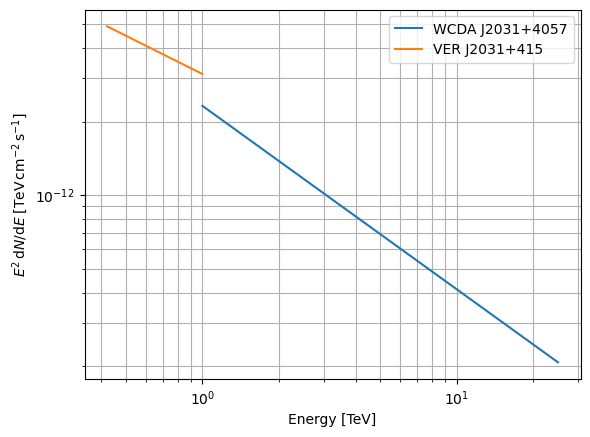

In [3]:
# LHAASO J2031+4127u (VER J2032+414 - TeV J2032+4130 - MGRO J2031+41) 
energy_bounds_WCDA = [1, 25] * u.TeV
model_WCDA = PowerLawSpectralModel(
    index=2.75,
    amplitude="0.11e-9 TeV-1 m-2 s-1",
    reference=7 * u.TeV,
)
energy_WCDA = np.logspace(np.log10(1), np.log10(25), 200) * u.TeV


dnde_WCDA = model_WCDA(energy_WCDA)
e2dnde_WCDA = (energy_WCDA**2 * dnde_WCDA).to("TeV cm-2 s-1")


energy_bounds = [422, 42200] * u.GeV
model_VER= PowerLawSpectralModel(index=2.52,amplitude="1.44e-8 GeV-1 cm-2 s-1", reference=2.27 * u.GeV,)

energy_VER = np.logspace(np.log10(0.422), np.log10(1), 200) * u.TeV
dnde_VER = model_VER(energy_VER)
e2dnde_VER = (energy_VER**2 * dnde_VER).to("TeV cm-2 s-1")


plt.loglog(energy_WCDA, e2dnde_WCDA, label="WCDA J2031+4057")
plt.loglog(energy_VER, e2dnde_VER, label="VER J2031+415")
plt.xlabel("Energy [TeV]")
plt.ylabel(r"$E^2\,\mathrm{d}N/\mathrm{d}E\;[\mathrm{TeV\,cm^{-2}\,s^{-1}}]$")
plt.legend()
plt.grid(which="both")
plt.show()

In [4]:
en_points = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20] * u.TeV
E2DNDE = []

for i in en_points:
    if i <= 1 * u.TeV:
        dnde = model_VER(i).to(1 / (u.TeV * u.cm**2 * u.s))
    else:
        dnde = model_WCDA(i).to(1 / (u.TeV * u.cm**2 * u.s))
    
    # Calcolo E^2 * dN/dE e converto in numeri puri
    value = ((i**2) * dnde).to(u.TeV * u.cm**(-2) * u.s**(-1)).value
    E2DNDE.append(value)

print(E2DNDE)
err_points = [0,0,0,0,0,0,0,]

[np.float64(5.040532934417495e-12), np.float64(4.4883141824193536e-12), np.float64(4.082338398947404e-12), np.float64(3.7678766038202585e-12), np.float64(3.5151256926547122e-12), np.float64(3.3062945962967668e-12), np.float64(3.1300238892600455e-12), np.float64(1.7113697489369962e-12), np.float64(1.3792398558300754e-12), np.float64(1.0175865409181483e-12), np.float64(8.201009249242264e-13), np.float64(6.937209209087234e-13), np.float64(6.050605772954349e-13), np.float64(5.39e-13), np.float64(4.876349274701012e-13), np.float64(4.4640640081086425e-13), np.float64(4.1248892748544684e-13), np.float64(2.452673837127675e-13)]


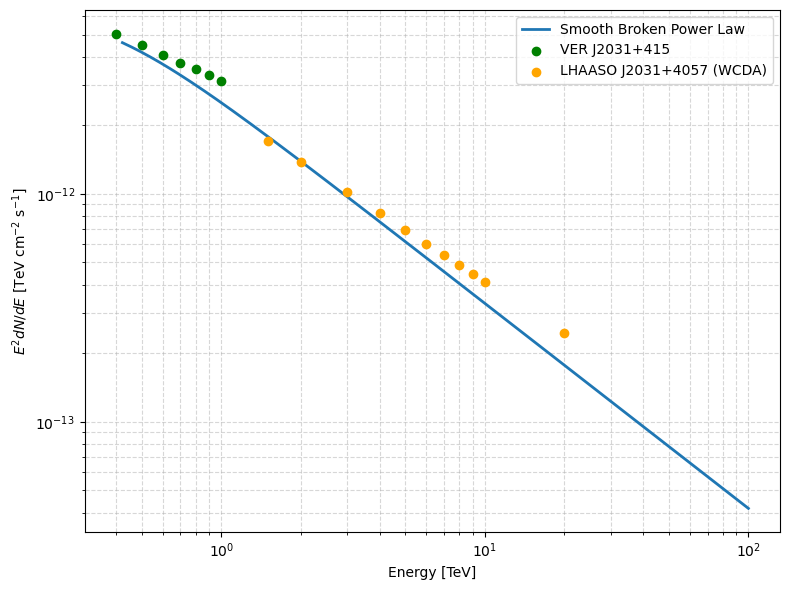

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from gammapy.modeling.models import SmoothBrokenPowerLawSpectralModel

# Modello
model = SmoothBrokenPowerLawSpectralModel(
    index1=1,
    index2=2.9,
    amplitude="0.8e-11 TeV-1 cm-2 s-1",
    ebreak="0.2 TeV",
    reference="7 TeV",
    beta=1,
)

# Energia per il modello
energy = np.logspace(np.log10(0.422), np.log10(100), 200) * u.TeV
dnde = model(energy)
e2dnde_model = (energy**2 * dnde).to("TeV cm-2 s-1")

# Conversione punti sperimentali
en_points_TeV = en_points.to(u.TeV).value

# Plot unico
plt.figure(figsize=(8, 6))

# Modello
plt.plot(
    energy.to(u.TeV).value,
    e2dnde_model.value,
    label="Smooth Broken Power Law",
    lw=2,
)

# Punti spettrali
plt.scatter(
    en_points_TeV[:7],
    E2DNDE[:7],
    color="green",
    zorder=3,
    label="VER J2031+415",
)

plt.scatter(
    en_points_TeV[7:],
    E2DNDE[7:],
    color="orange",
    zorder=3,
    label="LHAASO J2031+4057 (WCDA)",
)

# Assi e stile
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [TeV]")
plt.ylabel(r"$E^2 dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [30]:
ra = 307.89 * u.deg
dec = 40.96 * u.deg

c = SkyCoord(ra=ra, dec=dec, frame='icrs')

lon = c.galactic.l.deg * u.degx
lat = c.galactic.b.deg * u.deg

print(lon, lat)


gauss = GaussianSpatialModel(lon_0=lon, lat_0=lat, sigma="0.33 deg")
OB2model = SkyModel(spatial_model=gauss,  spectral_model=model, name="LHAASO J2031+4057  +   VER J2031+415")
models = Models([OB2model])

print(models.to_yaml())
models.write("0B2_model.yaml", overwrite=True)

79.75005291943432 deg 0.8336845416680935 deg
components:
-   name: LHAASO J2031+4057  +   VER J2031+415
    type: SkyModel
    spectral:
        type: SmoothBrokenPowerLawSpectralModel
        parameters:
        -   name: index1
            value: 1.0
        -   name: index2
            value: 2.9
        -   name: amplitude
            value: 8.0e-12
            unit: TeV-1 s-1 cm-2
        -   name: ebreak
            value: 0.2
            unit: TeV
        -   name: reference
            value: 7.0
            unit: TeV
        -   name: beta
            value: 1.0
    spatial:
        type: GaussianSpatialModel
        frame: icrs
        parameters:
        -   name: lon_0
            value: 79.75005291943432
            unit: deg
        -   name: lat_0
            value: 0.8336845416680935
            unit: deg
        -   name: sigma
            value: 0.33
            unit: deg
        -   name: e
            value: 0.0
        -   name: phi
            value: 0.0
         